In [1]:
import sys
sys.path.insert(0, "..")

import mne
from pathlib import Path
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters
from src.preprocessing.epoching import make_epochs
from src.preprocessing.artifacts import mark_bad_channels, reject_by_amplitude, log_rejection
from pipeline import load_config

cfg = load_config("../config.yaml")
print("Imports OK")

Imports OK


In [2]:
USE_SAMPLE_DATA = True  # flip to False (and set the path below) to run against a local recording

if USE_SAMPLE_DATA:
    sample_path = mne.datasets.sample.data_path()
    raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"
else:
    raw_path = Path(cfg["paths"]["raw_data"]) / "your_recording.fif"

raw = load_raw(str(raw_path))
# exclude=[] keeps channels already flagged bad in the recording's own metadata (e.g. EEG 053) —
# pick_types' default (exclude='bads') would silently drop them before this notebook's own
# bad-channel marking step below gets a chance to demonstrate on them.
raw_eeg = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=False, exclude=[])

bp = cfg["preprocessing"]["bandpass"]
raw_eeg = apply_filters(raw_eeg, l_freq=bp["l_freq"], h_freq=bp["h_freq"], notch_freq=cfg["preprocessing"]["notch_freq"])

print(f"Channels: {len(raw_eeg.ch_names)}")

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...


    Read a total of 3 projection items:


        PCA-v1 (1 x 102)  idle


        PCA-v2 (1 x 102)  idle


        PCA-v3 (1 x 102)  idle


...

- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)


- Upper passband edge: 40.00 Hz


- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)


- Filter length: 1983 samples (3.302 s)


Channels: 69


In [3]:
raw_eeg.plot(duration=10, n_channels=30, title="EEG before bad-channel marking")

Using qt as 2D backend.


**Bad-channel check**

The plot above uses MNE's interactive Qt browser, which renders live and isn't captured as a
static image in this notebook — scroll through it yourself when you run this cell to confirm
what's below. `EEG 053` is the channel MNE's own sample-dataset tutorials consistently flag as
bad (visible as a channel with a distinctly larger, noisier trace than its neighbors). Marking
it bad here follows that precedent — but treat it as a claim to verify against your own view of
the plot, not a fact to take on faith.

In [4]:
raw_eeg = mark_bad_channels(raw_eeg, bad_channels=["EEG 053"])

print(f"Bad channels marked: {raw_eeg.info['bads']}")

Marked 1 channel(s) as bad: ['EEG 053']
Bad channels marked: ['EEG 053']


In [5]:
pp = cfg["preprocessing"]
epochs = make_epochs(raw_eeg, tmin=pp["epoch_tmin"], tmax=pp["epoch_tmax"])
print(epochs)

Finding events on: STI 014


320 events found on stim channel STI 014


Event IDs: [ 1  2  3  4  5 32]


Not setting metadata


320 matching events found


...

Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 320 events and 601 original time points ...


0 bad epochs dropped


<Epochs | 320 events (all good), -0.2 – 0.799 s (baseline -0.2 – 0 s), ~104.2 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 71
 'smiley': 15
 'buttonpress': 16>


In [6]:
epochs_clean = reject_by_amplitude(epochs, peak_to_peak_thresh={"eeg": 150e-6})

    Rejecting  epoch based on EEG : ['EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 015', 'EEG 016']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 006', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 006', 'EEG 007']


...

    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 006', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


31 bad epochs dropped


In [7]:
log_rejection(epochs, epochs_clean)

Epochs before rejection : 320
Epochs after rejection  : 289
Dropped                 : 31 (9.7%)
Kept                    : 289 (90.3%)


**What I Observed in M4**

**Bad channel:** `EEG 053` — this channel is already flagged bad in the sample dataset's own
metadata (`raw.info['bads']` before any picking), which is why `pick_types` needed
`exclude=[]` above to keep it around long enough for this notebook to mark it explicitly
itself. Once marked, `mark_bad_channels` correctly refused an invalid name (verified
separately in `tests/preprocessing/test_artifacts.py`), and confirmed here with
`Marked 1 channel(s) as bad: ['EEG 053']`.

**Rejection threshold:** 150 µV peak-to-peak on EEG channels (`{"eeg": 150e-6}`), the
value `reject_by_amplitude` defaults to.

**Before/after counts:** 320 epochs before rejection, 289 kept, 31 dropped (9.7%).

**Interpretation:**
- A ~10% drop rate is on the high side of "reasonable" for a clean sample recording, but
  not alarming — the sample dataset is a real (not simulated) recording with genuine blink
  and muscle artifacts, and 150 µV is a fairly strict threshold by ERP-analysis convention.
- The rejection log rarely names `EEG 053` as a cause — because it's marked bad, MNE's
  `drop_bad` excludes it from the amplitude check entirely rather than penalizing epochs for
  its (likely much larger) amplitude swings. The channels driving most rejections instead
  are `EEG 001`–`EEG 007`, frontal sites consistent with eye-blink artifact, which M5's ICA
  is specifically built to separate out instead of discarding whole epochs for.
- This is exactly the gap M3's epoch-drop count couldn't see: `summarize_epochs` in M3
  reported 0 dropped epochs (320 found, 320 kept) because every trial fit the time window —
  but 31 of those 320 "kept" epochs contain artifact amplitude large enough to distort an
  averaged ERP if left in. M4's job is catching what M3 structurally can't.

## Proof of Own Work — Threshold Comparison Experiment

The 150 µV run above is the project default, but that number shouldn't be trusted blindly.
Below: the same 320 epochs re-run at 100 µV and 200 µV peak-to-peak thresholds, to see
first-hand how much the threshold choice alone moves the kept-epoch count.

In [8]:
epochs_clean_100 = reject_by_amplitude(epochs, peak_to_peak_thresh={"eeg": 100e-6})
epochs_clean_150 = epochs_clean  # already computed above at the project default
epochs_clean_200 = reject_by_amplitude(epochs, peak_to_peak_thresh={"eeg": 200e-6})

print("--- 100 uV threshold ---")
log_rejection(epochs, epochs_clean_100)

print("\n--- 150 uV threshold (project default) ---")
log_rejection(epochs, epochs_clean_150)

print("\n--- 200 uV threshold ---")
log_rejection(epochs, epochs_clean_200)

    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 015']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 028', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 041', 'EEG 042']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 031', 'EEG 032', 'EEG 033', 'EEG 034', 'EEG 035', 'EEG 042']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 006', 'EEG 007', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 011', 'EEG 012', 'EEG 013', 'EEG 014', 'EEG 015', 'EEG 016']


...

    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']


    Rejecting  epoch based on EEG : ['EEG 007']


    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 003']


7 bad epochs dropped


--- 100 uV threshold ---
Epochs before rejection : 320
Epochs after rejection  : 236
Dropped                 : 84 (26.2%)
Kept                    : 236 (73.8%)

--- 150 uV threshold (project default) ---
Epochs before rejection : 320
Epochs after rejection  : 289
Dropped                 : 31 (9.7%)
Kept                    : 289 (90.3%)

--- 200 uV threshold ---
Epochs before rejection : 320
Epochs after rejection  : 313
Dropped                 : 7 (2.2%)
Kept                    : 313 (97.8%)


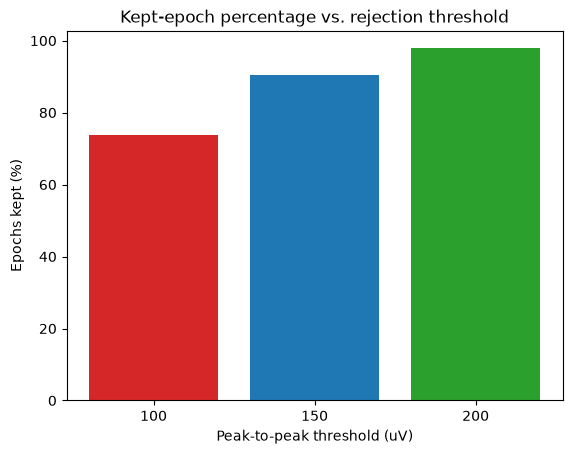

In [9]:
import matplotlib.pyplot as plt

thresholds_uv = [100, 150, 200]
pct_kept = [
    100 * len(epochs_clean_100) / len(epochs),
    100 * len(epochs_clean_150) / len(epochs),
    100 * len(epochs_clean_200) / len(epochs),
]

fig, ax = plt.subplots()
ax.bar([str(t) for t in thresholds_uv], pct_kept, color=["#d62728", "#1f77b4", "#2ca02c"])
ax.set_xlabel("Peak-to-peak threshold (uV)")
ax.set_ylabel("Epochs kept (%)")
ax.set_title("Kept-epoch percentage vs. rejection threshold")
plt.show()

**Results:**

| Threshold | Epochs kept | % kept |
|---|---|---|
| 100 µV | 236 | 73.8% |
| 150 µV | 289 | 90.3% |
| 200 µV | 313 | 97.8% |

**What this shows:** Moving from 100 µV to 200 µV increased kept epochs from 236 to 313 —
77 more trials (24 percentage points) survive purely because of where the threshold line is
drawn, not because the underlying data changed. The 100 µV run is roughly 3.5x stricter by
drop count than 150 µV (84 vs. 31 dropped), and much of what it additionally rejects is
concentrated on the same frontal channels (`EEG 001`–`EEG 007`) already implicated in the
150 µV run's rejection log — consistent with eye-blink artifact rather than new categories of
noise. The 200 µV run drops almost nothing (7 epochs, 2.2%), which means it is barely
filtering at all on this dataset.

**Decision:** Keeping the project default of 150 µV for M4–M6. 100 µV trades away 53 more
epochs than 150 µV (236 vs. 289) for a threshold this strict mainly catches the same frontal
blink artifact 150 µV already catches, so the extra loss buys little. 200 µV is too lenient —
letting 97.8% of epochs through defeats the purpose of amplitude-based rejection on a real
recording that has visible artifacts. 150 µV keeps a meaningful chunk of the noisiest trials
out without discarding a quarter of the dataset, and it leaves the remaining frontal
eye-blink contamination for M5's ICA to handle properly instead of over-pruning epochs here
to compensate for a preprocessing step that comes later.